# Federated Learning with FedAvg under IID Data

## Objective

This notebook implements the Federated Averaging (FedAvg) algorithm on the MNIST dataset using an IID client distribution.

The goal is to evaluate whether Federated Learning can achieve performance comparable to centralized training while keeping data distributed across clients.


In [17]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


## Environment Setup

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## Experimental Configuration

- Number of Clients: 5
- Communication Rounds: 5
- Local Epochs: 1
- Batch Size: 64
- Learning Rate: 0.001


In [19]:
NUM_CLIENTS = 5
ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
LR = 0.001


## Dataset

MNIST is divided equally among five clients using a random IID split.

Each client receives approximately the same class distribution.


In [20]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    './data',
    train=False,
    download=True,
    transform=transform
)


In [21]:
client_size = len(train_dataset) // NUM_CLIENTS

client_datasets = random_split(
    train_dataset,
    [client_size] * NUM_CLIENTS
)

client_loaders = [
    DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    for ds in client_datasets
]

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

for i, ds in enumerate(client_datasets):
    print(f'Client {i+1}: {len(ds)} samples')


Client 1: 12000 samples
Client 2: 12000 samples
Client 3: 12000 samples
Client 4: 12000 samples
Client 5: 12000 samples


## Model Architecture

The same CNN architecture used in the centralized baseline is reused to ensure fair comparison.


In [22]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32,3)
        self.conv2 = nn.Conv2d(32,64,3)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64*12*12,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))

        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))

        return self.fc2(x)


## Local Client Training

In [23]:
def train_local_model(model, loader):

    model.train()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )

    criterion = nn.CrossEntropyLoss()

    for _ in range(LOCAL_EPOCHS):

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            loss = criterion(
                model(images),
                labels
            )

            loss.backward()

            optimizer.step()

    return model


In [24]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total


## Federated Averaging

FedAvg aggregates the parameters received from all participating clients by computing their average.


In [25]:
def federated_average(client_models):

    global_model = copy.deepcopy(client_models[0])

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack(
            [m.state_dict()[key].float() for m in client_models],
            dim=0
        ).mean(dim=0)

    global_model.load_state_dict(global_dict)

    return global_model


## Federated Training

In [26]:
global_model = CNN().to(device)

accuracy_history = []


In [27]:
for round_num in range(ROUNDS):

    print(f'\n===== ROUND {round_num+1} =====')

    client_models = []

    for client_id in range(NUM_CLIENTS):

        local_model = copy.deepcopy(global_model)

        local_model = train_local_model(
            local_model,
            client_loaders[client_id]
        )

        client_models.append(local_model)

    global_model = federated_average(client_models)

    accuracy = evaluate(
        global_model,
        test_loader
    )

    accuracy_history.append(accuracy)

    print(f'Global Accuracy: {accuracy:.2f}%')



===== ROUND 1 =====
Global Accuracy: 93.85%

===== ROUND 2 =====
Global Accuracy: 98.13%

===== ROUND 3 =====
Global Accuracy: 98.74%

===== ROUND 4 =====
Global Accuracy: 98.95%

===== ROUND 5 =====
Global Accuracy: 99.05%


## Convergence Analysis

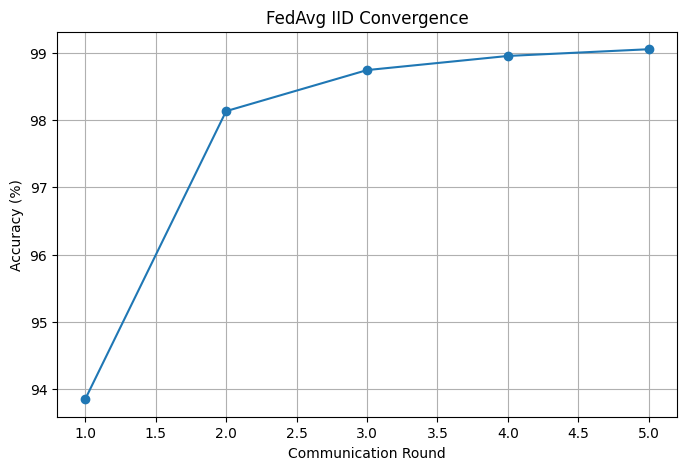

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,ROUNDS+1),
    accuracy_history,
    marker='o'
)

plt.xlabel('Communication Round')
plt.ylabel('Accuracy (%)')
plt.title('FedAvg IID Convergence')

plt.grid()

plt.savefig(
    'fedavg_iid_accuracy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Results

In [31]:
CENTRALIZED_BASELINE = 98.93

print(f'Centralized Accuracy : {CENTRALIZED_BASELINE:.2f}%')
print(f'FedAvg IID Accuracy  : {accuracy_history[-1]:.2f}%')
print(f'Difference           : {CENTRALIZED_BASELINE - accuracy_history[-1]:.2f}%')


Centralized Accuracy : 98.93%
FedAvg IID Accuracy  : 99.05%
Difference           : -0.12%


## Conclusion

FedAvg achieved approximately 99.05% accuracy under IID conditions.
